In [20]:
from resources.imports import *

from resources.lattices import geometry, pStrainProperties, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, remove_outliers, split_data, plot_sampling,\
                             locSims, get_stats, plot_frequency, plot_properties, plot_curve

In [31]:
### Global Inputs

MODEL = 'ductile'      # ductile, fracture, both
DAT = DATA(path=1, LAT="hex", dis="disNodes", dN=20)

l = 0.010
if DAT.LAT.lower() == "fcc" or DAT.LAT.lower() == "kagome" or DAT.LAT.lower() == "hex":
    nnx = 20
elif DAT.LAT.lower() == "tri":
    nnx = 30

# Load Data

In [32]:
UT_CSVin  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
UT_CSVout = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
FT_CSVin  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
FT_CSVout = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'

In [33]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_IN_df, UT_OUT_df, UT_perIN_df, UT_perOUT_df, UT_dIN_df, UT_dOUT_df = load_data(UT_CSVin, UT_CSVout)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_IN_df, FT_OUT_df, FT_perIN_df, FT_perOUT_df, FT_dIN_df, FT_dOUT_df = load_data(FT_CSVin, FT_CSVout)

# Geometry

In [34]:
geom = geometry(DAT.LAT, l, nnx, FTcalc=True)

E = 123e9  ## Pa
v = 0.3
rD = 0.2
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(DAT.LAT, E_pStrain, rD)

# Prep Data

In [35]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_dIN_r, UT_dOUT_r, UT_xOUT, UT_props_r = prep_UTdata(UT_dIN_df, UT_dOUT_df, UT_perOUT_df, UT_OUT_df)
    UT_dIN, UT_dOUT, UT_props, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df = remove_outliers(UT_dIN_r, UT_dOUT_r, UT_props_r, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df)
    UT_train_in, UT_train_out, UTval_in, UTval_out, UT_test_in, UT_test_out = split_data(UT_dIN[1:], UT_dOUT[1:], DAT.PATH, mode="UT", dis=DAT.dis, split=0.85)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_dIN_r, FT_dOUT_r, FT_xOUT, FT_props_r = prep_FTdata(FT_dIN_df, FT_dOUT_df, FT_perOUT_df, FT_OUT_df, geom, E_eff)
    FT_dIN, FT_dOUT, FT_props, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df = remove_outliers(FT_dIN_r, FT_dOUT_r, FT_props_r, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df)
    FT_train_in, FT_train_out, FT_val_in, FT_val_out, FT_test_in, FT_test_out = split_data(FT_dIN[1:], FT_dOUT[1:], DAT.PATH, mode="FT", dis=DAT.dis, split=0.85)

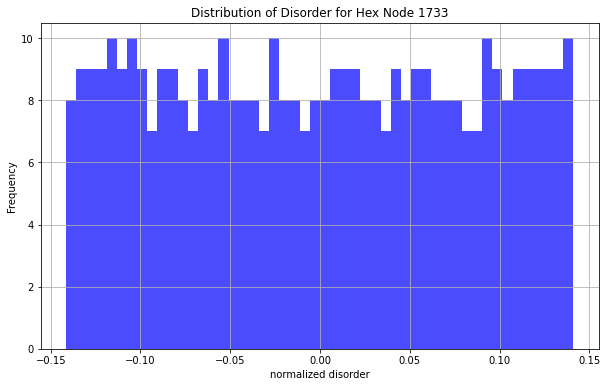

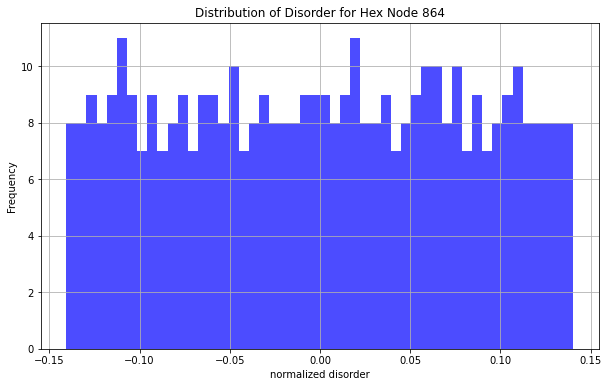

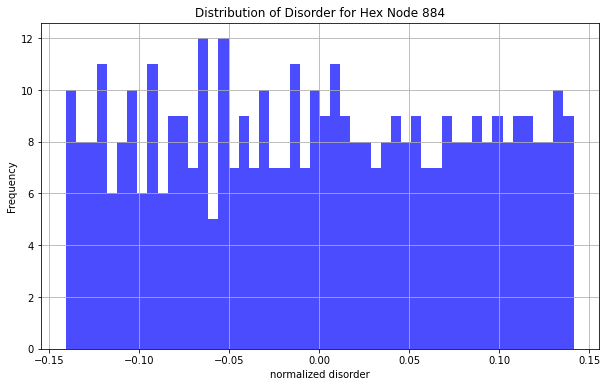

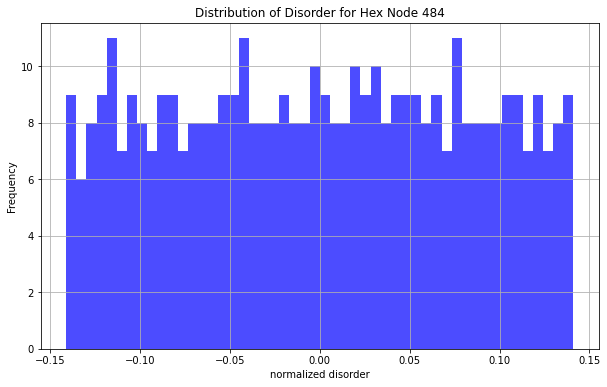

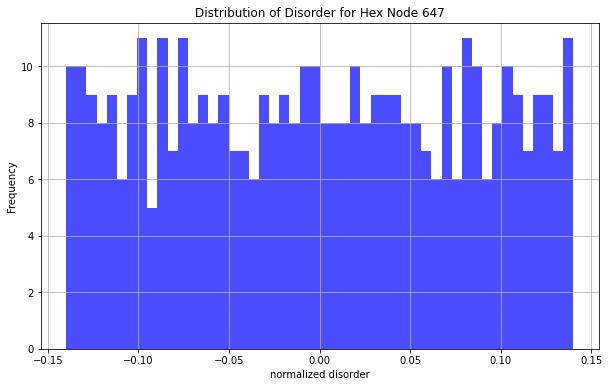

In [36]:
plot_sampling(UT_dIN_df, DAT.LAT, l, indx=None, num=5, by="node")

In [37]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_stats = get_stats(UT_props)
    UT_nSim_max, UT_nSim_min = locSims(UT_props[0], UT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(UT_OUT_df)-1)
    print(f"UT -- max: {UT_nSim_max}, min: {UT_nSim_min} \nStats: {np.array(UT_stats)/UT_props[0][0]} \n")
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_stats = get_stats(FT_props)
    FT_nSim_max, FT_nSim_min = locSims(FT_props[0], FT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(FT_OUT_df)-1)
    print(f"FT -- max: {FT_nSim_max}, min: {FT_nSim_min} \nStats: {np.array(FT_stats)/FT_props[0][0]} \n")

FINAL SIMULATION COUNT: 424
UT -- max: 424, min: 94 
Stats: [[9.40442603e-01 7.36939303e-02]
 [1.59627340e+02 3.71180117e+00]
 [1.15070815e+04 3.50992436e+02]] 



# Plot Distribution & Identify Max, Min Simulations

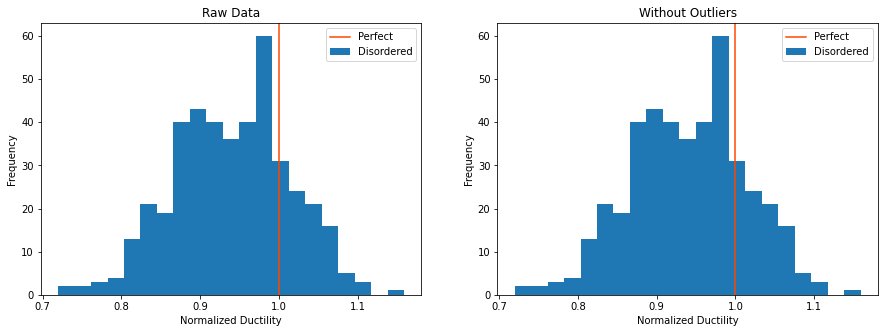

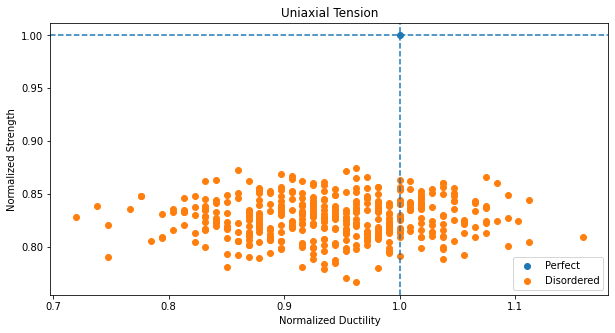

In [38]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(UT_props_r[U1], UT_props[U1], "UT", bins=len(UT_props[U1])//20)
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(FT_props_r[F1], FT_props[F1], "FT", bins=len(FT_props[U1])//20)

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_properties(UT_props[U1], UT_props[U2], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_properties(FT_props[F1], FT_props[F2], "FT")

# Plots UT and FT Curves

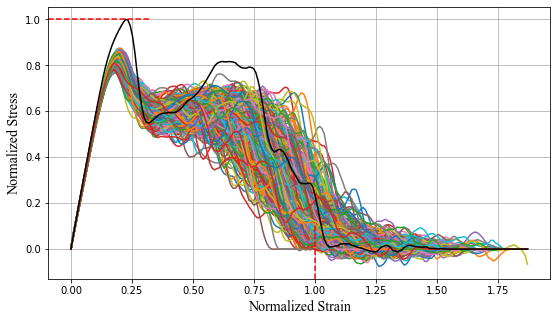

In [39]:
idx = None
q   = "all"
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plot_curve(UT_OUT_df, UT_xOUT, "ut", idx=idx, q='all')
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plot_curve(FT_OUT_df, FT_xOUT, "ft", idx=idx, q='all')